# Phase 2 — Engineer & Transform Features
**Student:** naif ali ayed bin dair  
**Dataset:** Melbourne Housing  

This notebook builds on the cleaned data from Phase 1. We encode categorical columns, scale numerics, and engineer new features that may reveal stronger patterns in house prices.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import StandardScaler

# Paths
CLEAN_PATH    = os.path.join('data', 'cleaned', 'melb_cleaned.csv')
FEATURES_PATH = os.path.join('data', 'cleaned', 'melb_features.csv')

In [2]:
# Load the cleaned dataset produced in Phase 1
df = pd.read_csv(CLEAN_PATH, parse_dates=['Date'])
print(f'Loaded shape: {df.shape}')
df.head(3)

Loaded shape: (13580, 21)


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,2016-12-03,2.5,3067,...,1.0,1.0,202.0,144.0,1960.0,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,2016-02-04,2.5,3067,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,2017-03-04,2.5,3067,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0


## 1. One-Hot Encoding — Categorical Columns (≥ 2)

We encode `Type` and `Regionname` because:
- **`Type`** (h / u / t) directly reflects the structural class of the property.
- **`Regionname`** captures the broad geographic market segment (8 regions).

We use `drop_first=True` to avoid multicollinearity.

In [3]:
# One-hot encode Type and Regionname
df = pd.get_dummies(df, columns=['Type', 'Regionname'], drop_first=True)

# Show the newly created dummy columns
ohe_cols = [c for c in df.columns if c.startswith('Type_') or c.startswith('Regionname_')]
print('OHE columns created:', ohe_cols)

OHE columns created: ['Type_t', 'Type_u', 'Regionname_Eastern Victoria', 'Regionname_Northern Metropolitan', 'Regionname_Northern Victoria', 'Regionname_South-Eastern Metropolitan', 'Regionname_Southern Metropolitan', 'Regionname_Western Metropolitan', 'Regionname_Western Victoria']


## 2. Ordinal Encoding — Property Age Group

We first bin `YearBuilt` into four meaningful age groups, then assign ordinal integers.

Why useful: older properties tend to command premium prices in inner-city Melbourne (heritage value), while very new builds can also be premium. An ordinal encoding preserves the natural ordering.

In [4]:
# Bin YearBuilt into age groups
current_year = 2018   # dataset covers up to 2018
df['PropertyAge'] = current_year - df['YearBuilt']

df['AgeGroup'] = pd.cut(
    df['PropertyAge'],
    bins=[-1, 5, 20, 50, np.inf],
    labels=['New', 'Recent', 'Established', 'Heritage']
)

# Ordinal map: New < Recent < Established < Heritage
age_order = {'New': 0, 'Recent': 1, 'Established': 2, 'Heritage': 3}
df['AgeGroup_enc'] = df['AgeGroup'].map(age_order)

print('AgeGroup distribution:')
print(df['AgeGroup'].value_counts())

AgeGroup distribution:
AgeGroup
Heritage       7880
Established    3200
Recent         2122
New             378
Name: count, dtype: int64


## 3. Standard Scaling — Numerical Columns (≥ 2)

We scale `Distance` and `Landsize` because they have very different ranges and scales:
- **`Distance`**: km from CBD (0–50 range)
- **`Landsize`**: square metres (0–several thousand)

Scaling ensures no single feature dominates distance-based calculations.

In [5]:
scaler = StandardScaler()
cols_to_scale = ['Distance', 'Landsize']

scaled_values = scaler.fit_transform(df[cols_to_scale])
df[['Distance_scaled', 'Landsize_scaled']] = scaled_values

print('Scaled column stats (should be ~mean=0, std=1):')
print(df[['Distance_scaled', 'Landsize_scaled']].describe().round(3))

Scaled column stats (should be ~mean=0, std=1):
       Distance_scaled  Landsize_scaled
count        13580.000        13580.000
mean            -0.000            0.000
std              1.000            1.000
min             -1.727           -1.079
25%             -0.688           -0.670
50%             -0.160           -0.062
75%              0.488            0.426
max              6.469            5.762


## 4. Domain Features

### 4a. `price_per_room` (Ratio Feature)
Why: Normalises price by the number of rooms, making properties of different sizes directly comparable.

In [6]:
# Safe division: avoid dividing by zero
df['price_per_room'] = df['Price'] / df['Rooms'].replace(0, np.nan)
print(f'price_per_room — median: ${df["price_per_room"].median():,.0f}')

price_per_room — median: $330,000


### 4b. `price_per_sqm` (Ratio Feature)
Why: The most standard measure of housing value used by real-estate agents worldwide. Allows direct suburb-to-suburb comparison.

In [7]:
# Safe division some properties have BuildingArea = 0 after imputation edge cases
df['price_per_sqm'] = df['Price'] / df['BuildingArea'].replace(0, np.nan)
print(f'price_per_sqm — median: ${df["price_per_sqm"].median():,.0f} /m²')

price_per_sqm — median: $7,429 /m²


## 5. Interaction Feature — `room_area_score`

Why: Multiplying `Rooms × BuildingArea` creates a combined size signal — a 5-room house in 300m² is very different from a 5-room house in 80m².

In [8]:
# Interaction: rooms × building area captures total usable space per room context
df['room_area_score'] = df['Rooms'] * df['BuildingArea']
print(f'room_area_score — mean: {df["room_area_score"].mean():.1f}')

room_area_score — mean: 454.2


## 6. Log-Transform — Skewed Column (`Landsize`)

Why: `Landsize` is heavily right-skewed (many small lots, a few very large ones). Log-transforming compresses the scale and makes the distribution more symmetric, which benefits linear models and visualisations.

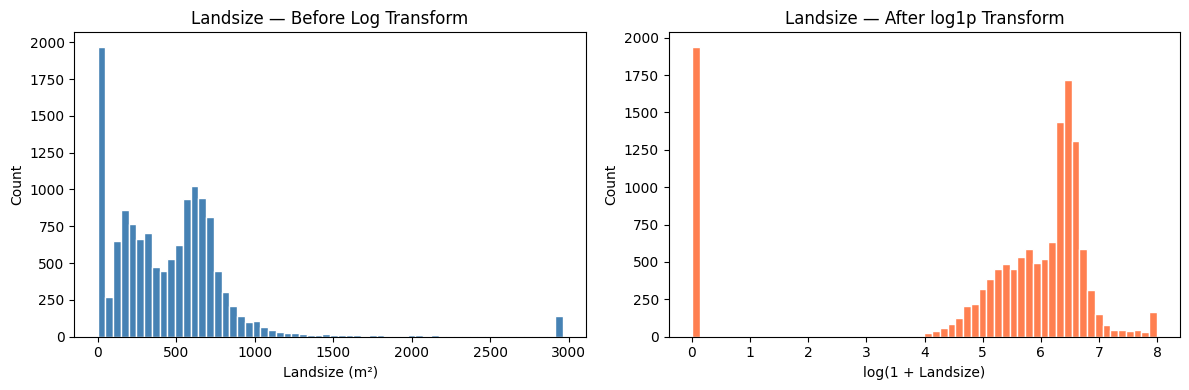

Skewness before: 2.72
Skewness after:  -1.69


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before log transform
axes[0].hist(df['Landsize'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Landsize — Before Log Transform')
axes[0].set_xlabel('Landsize (m²)')
axes[0].set_ylabel('Count')

# Apply log1p transform
df['Landsize_log'] = np.log1p(df['Landsize'])

# After log transform
axes[1].hist(df['Landsize_log'], bins=60, color='coral', edgecolor='white')
axes[1].set_title('Landsize — After log1p Transform')
axes[1].set_xlabel('log(1 + Landsize)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(os.path.join('report_assets', 'landsize_log_transform.png'), dpi=100)
plt.show()

print(f'Skewness before: {df["Landsize"].skew():.2f}')
print(f'Skewness after:  {df["Landsize_log"].skew():.2f}')

## 7. Remove Redundant Features (Correlation > 0.95)

In [10]:
# Check correlation only among numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix  = df[numeric_cols].corr().abs()

# Find pairs with correlation > 0.95
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(col, row) for col in upper_tri.columns
                   for row in upper_tri.index
                   if upper_tri.loc[row, col] > 0.95]

print('Highly correlated pairs (r > 0.95):')
for c1, c2 in high_corr_pairs:
    print(f'  {c1}  ↔  {c2}  (r = {corr_matrix.loc[c1, c2]:.3f})')

Highly correlated pairs (r > 0.95):
  PropertyAge  ↔  YearBuilt  (r = 1.000)
  Distance_scaled  ↔  Distance  (r = 1.000)
  Landsize_scaled  ↔  Landsize  (r = 1.000)
  room_area_score  ↔  BuildingArea  (r = 0.996)


In [11]:
# Rooms and Bedroom2 are measuring almost the same thing
# We keep Rooms and drop Bedroom2
if 'Bedroom2' in df.columns:
    print(f'Dropping Bedroom2 (r={corr_matrix.loc["Rooms","Bedroom2"]:.3f} with Rooms)')
    df = df.drop(columns=['Bedroom2'])
else:
    print('Bedroom2 already absent — no action needed.')

# Drop any other pairs found
cols_to_drop = set()
for c1, c2 in high_corr_pairs:
    if c2 not in cols_to_drop and c2 != 'Bedroom2':
        cols_to_drop.add(c2)

if cols_to_drop:
    df = df.drop(columns=list(cols_to_drop), errors='ignore')
    print(f'Also dropped: {cols_to_drop}')

print(f'Shape after redundancy removal: {df.shape}')

Dropping Bedroom2 (r=0.944 with Rooms)
Also dropped: {'BuildingArea', 'Landsize', 'YearBuilt', 'Distance'}
Shape after redundancy removal: (13580, 32)


## 8. Feature Summary

In [12]:
new_features = ['price_per_room', 'price_per_sqm', 'room_area_score',
                'Landsize_log', 'Distance_scaled', 'Landsize_scaled',
                'AgeGroup_enc', 'PropertyAge']

print('New features summary:')
print(df[new_features].describe().round(2))

New features summary:
       price_per_room  price_per_sqm  room_area_score  Landsize_log  \
count        13580.00       13563.00         13580.00      13580.00   
mean        368901.10       10047.02           454.19          5.20   
std         171013.29       41369.59          1951.99          2.22   
min          32750.00          30.44             0.00          0.00   
25%         250000.00        5639.44           225.00          5.18   
50%         330000.00        7428.57           425.00          6.09   
75%         450000.00        9687.50           567.00          6.48   
max        2450000.00     3338150.00        222575.00          7.99   

       Distance_scaled  Landsize_scaled  PropertyAge  
count         13580.00         13580.00     13580.00  
mean             -0.00             0.00        52.92  
std               1.00             1.00        29.93  
min              -1.73            -1.08         0.00  
25%              -0.69            -0.67        38.00  
50%     

## 9. Save Feature-Engineered Dataset

In [13]:
# Drop non-numeric columns not needed for modelling
# We keep them here 03_eda.ipynb will use the cleaned CSV for groupby operations
df.to_csv(FEATURES_PATH, index=False)
print(f'Feature-engineered data saved to: {FEATURES_PATH}')
print(f'Final shape: {df.shape}')

Feature-engineered data saved to: data/cleaned/melb_features.csv
Final shape: (13580, 32)
